In [26]:
import wavespectra
from wavespectra import read_era5

dset = read_era5("output.nc") #output.nc acquired wave data name file
hs = dset.spec.hs()      # significant wave height
tp = dset.spec.tp()      # peak period
dm = dset.spec.dm()      # mean direction

print(dset)
dset.spec.hs()  # if this runs without error, the load succeeded fine

<xarray.Dataset> Size: 49MB
Dimensions:  (time: 120, dir: 24, freq: 30, lat: 13, lon: 11)
Coordinates:
  * time     (time) datetime64[ns] 960B 2020-04-01 ... 2020-04-30T18:00:00
  * dir      (dir) float64 192B 187.5 202.5 217.5 232.5 ... 142.5 157.5 172.5
  * freq     (freq) float64 240B 0.03453 0.03798 0.04178 ... 0.4527 0.498 0.5478
  * lat      (lat) float64 104B 6.0 5.5 5.0 4.5 4.0 3.5 ... 2.0 1.5 1.0 0.5 0.0
  * lon      (lon) float64 88B 95.0 95.5 96.0 96.5 97.0 ... 98.5 99.0 99.5 100.0
Data variables:
    efth     (time, dir, freq, lat, lon) float32 49MB dask.array<chunksize=(120, 24, 30, 13, 11), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-15T09:50 GRIB to CDM+CF via cfgrib-0.9.1...


<xarray.DataArray 'hs' (time: 120, lat: 13, lon: 11)> Size: 137kB
dask.array<mul, shape=(120, 13, 11), dtype=float64, chunksize=(120, 13, 11), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 960B 2020-04-01 ... 2020-04-30T18:00:00
  * lat      (lat) float64 104B 6.0 5.5 5.0 4.5 4.0 3.5 ... 2.0 1.5 1.0 0.5 0.0
  * lon      (lon) float64 88B 95.0 95.5 96.0 96.5 97.0 ... 98.5 99.0 99.5 100.0
Attributes:
    standard_name:  sea_surface_wave_significant_height
    units:          m

In [25]:
import xarray as xr
dset1 = xr.open_dataset("output.nc", engine="era5") #read_era5 and this line are similarly the same both callback era5 reasder
stats = dset1.spec.stats(["hs", "tp", "dpm", "dspr"])
print(stats)


<xarray.Dataset> Size: 413kB
Dimensions:  (time: 120, lat: 13, lon: 11)
Coordinates:
  * time     (time) datetime64[ns] 960B 2020-04-01 ... 2020-04-30T18:00:00
  * lat      (lat) float64 104B 6.0 5.5 5.0 4.5 4.0 3.5 ... 2.0 1.5 1.0 0.5 0.0
  * lon      (lon) float64 88B 95.0 95.5 96.0 96.5 97.0 ... 98.5 99.0 99.5 100.0
Data variables:
    hs       (time, lat, lon) float64 137kB dask.array<chunksize=(120, 13, 11), meta=np.ndarray>
    tp       (time, lat, lon) float32 69kB dask.array<chunksize=(120, 13, 11), meta=np.ndarray>
    dpm      (time, lat, lon) float32 69kB dask.array<chunksize=(120, 13, 11), meta=np.ndarray>
    dspr     (time, lat, lon) float64 137kB dask.array<chunksize=(120, 13, 11), meta=np.ndarray>
Attributes:
    standard_name:  sea_surface_wave_significant_height
    units:          m


In [32]:
dset.spec.hs() #transforms full spectrum into scalar into point statistic

<xarray.DataArray 'hs' (time: 120, lat: 13, lon: 11)> Size: 137kB
dask.array<mul, shape=(120, 13, 11), dtype=float64, chunksize=(120, 13, 11), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 960B 2020-04-01 ... 2020-04-30T18:00:00
  * lat      (lat) float64 104B 6.0 5.5 5.0 4.5 4.0 3.5 ... 2.0 1.5 1.0 0.5 0.0
  * lon      (lon) float64 88B 95.0 95.5 96.0 96.5 97.0 ... 98.5 99.0 99.5 100.0
Attributes:
    standard_name:  sea_surface_wave_significant_height
    units:          m

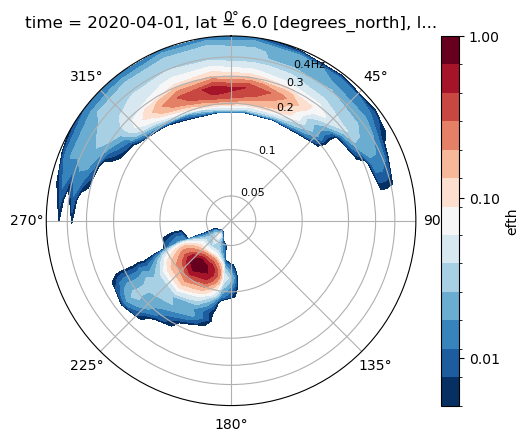

In [47]:
points = dset.sel(time="2020-04-01T00:00", lat=6, lon=96 ,method='nearest')
#wave spectrum data had three variables, code line above shows only in single timestep and coordinate. 
#very applicable for single hourly analysis
points.spec.plot(kind="contourf")
#from here we could see dominant wave direction, dominant frequency/period, seastate behavior(swell vs wind sea)
#diagnostic tool for understanding the composition of the sea state, not a substitute for the summary statistics or time-series analysis you'd layer on top of it

In [49]:
stats = dset.spec.stats(["hs", "tp", "tm01", "tm02", "dpm", "dspr"])

# Export a single grid point as a tidy time series
df = stats.isel(lat=0, lon=0).to_dataframe().reset_index()
df.to_csv("point_timeseries.csv", index=False)

# Or export a spatial snapshot at one time as a table
snap = stats.isel(time=0).to_dataframe().reset_index()

6.0 95.0
0.9187110796452443 1.9575894233828528 1.3033705721855189


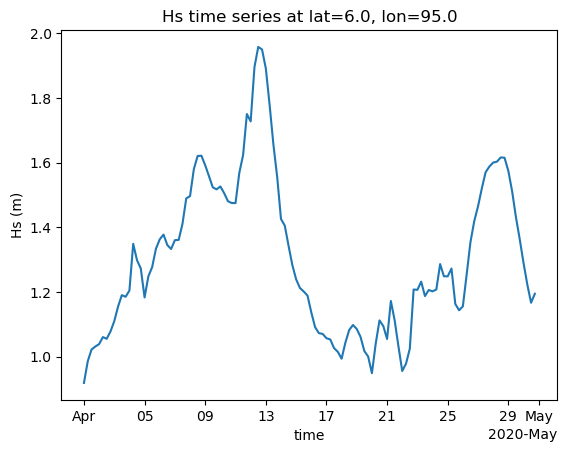

In [52]:
hs = dset.efth.spec.hs() 

# pick a point - let's use roughly the middle of your domain
point = hs.sel(lat=6, lon=95)   # check exact value
print(point.lat.values, point.lon.values)

# materialize and inspect actual numbers
point_vals = point.compute()
print(point_vals.min().values, point_vals.max().values, point_vals.mean().values)

import matplotlib.pyplot as plt

#plot timeseries from extracted
point_vals.plot()
plt.title(f"Hs time series at lat={float(point.lat.values):.1f}, lon={float(point.lon.values):.1f}")
plt.ylabel("Hs (m)")
plt.show()

Peak Hs occurred at: 2020-04-12T12:00:00.000000000
Calm period time: 2020-04-20T00:00:00.000000000



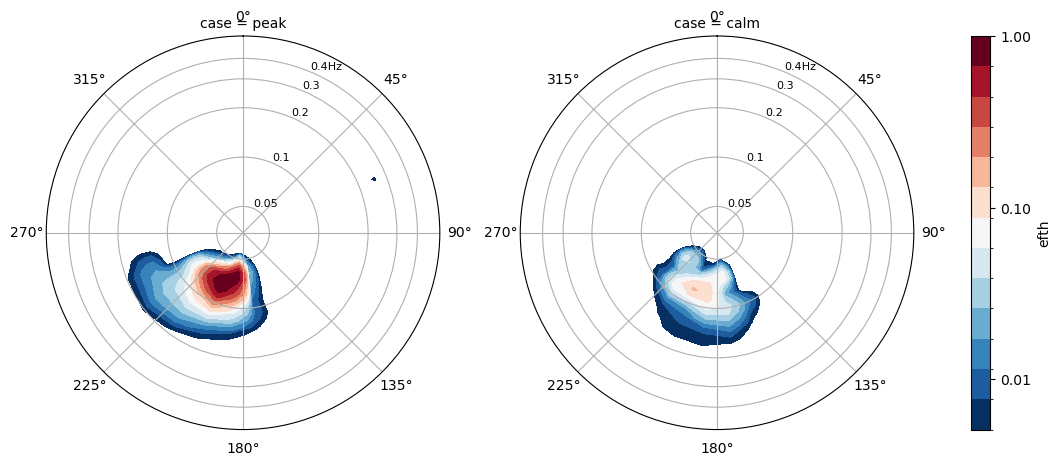

In [63]:
# find the time of maximum Hs at this point
peak_time = point_vals.idxmax(dim="time")
print("Peak Hs occurred at:", peak_time.values)

# also grab a calm-period time for comparison (the lull ~Apr 20)
import numpy as np
calm_time = point_vals.sel(time=slice("2020-04-19", "2020-04-23")).idxmin(dim="time")
print("Calm period time:", calm_time.values)
print( )
import xarray as xr

spec_peak= dset.sel(time=peak_time.values, lat=6, lon=95 ,method='nearest')
spec_calm= dset.sel(time=calm_time.values, lat=6, lon=95 ,method='nearest')

combined = xr.concat([spec_peak, spec_calm], dim="case")
combined = combined.assign_coords(case=["peak", "calm"])

combined.spec.plot(kind="contourf", col="case", figsize=(12, 5))
plt.show()